# The global wavelength mesh on real hydrogen

`spectra.Experimental.MALI.GlobalMesh` anchors every transition's
dimensionless template with one scalar ruler,
$\lambda = \lambda_0(1 + q\,\xi_{\rm ref}/c)$, and merges all transitions
into a single depth-independent axis with per-transition `(Nblue, span)`
windows — the precondition for any 1/2/3-D transfer solve, because the
transfer equation needs opacity at the *same* wavelength across all depths.
Here that machinery runs on **theoretical hydrogen** (9 bound levels +
continuum, 36 lines, 9 continua — no data files) to answer three questions
quantitatively:

1. **When does merging stop being trivial?** Window overlap versus wing
   extent, and what happens to `span` when lines interleave.
2. **What does the SE quadrature need?** The target architecture is the
   **dual mesh** (see `reference/RH_wavelength_mesh_explained.txt`): RT
   solves $J$ on the global axis; each (line, depth) integrates its rates on
   a local quadrature mesh recentered on the *shifted* line core and scaled
   by the *local* width, with $J$ **interpolated** global → local — the one
   deliberate in-loop approximation, placed on the smooth factor of
   $\varphi\,J$. We measure it against the **real quiet-Sun atlas** at
   H$\alpha$ and Ca II K, $V_{\rm los} = 0..300$ km/s, for a static *and* a
   co-moving background: the routes coincide statically (validation 1);
   under shifts the binding constraints are the mesh's extent and its
   density over the excursion band relative to $J$'s real structure, with
   dual-mesh contributing narrow-line ($\varphi$-side) accuracy at
   unchanged $N_{\rm spect}$ (validation 3).
3. **The interpolation seams at the pipeline edges**: tabulated
   photoionization cross sections $\alpha(\lambda)$ → global axis (input
   side, once, before the loop), and emergent intensity global axis →
   observational mesh (output side, after convergence).

This notebook is **generated** from `build_notebook.py` in this folder.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from spectra import Configurations as CFG
from spectra import Constants as CST
from spectra.Atomic import BasicP, Hydrogen, LTELib
from spectra.Experimental.MALI import GlobalMesh
from spectra.Struct.Atom import init_theoretical_hydrogen_atom_
from spectra.Util import MeshUtil

XI_REF = 1.0e6  # 10 km/s ruler; H thermal+turbulent width at 6 kK is ~11 km/s

atom = init_theoretical_hydrogen_atom_(10)  # n = 1..9 bound + continuum level
w0_all = atom.Line["w0"]
nLine = atom.nLine
cont_meshes = [atom._wave_mesh.Cont_mesh[k][::-1].copy() for k in range(atom.nCont)]  # ascending


def build_global(qwing, nLambda=41):
    q = MeshUtil.make_full_line_mesh_(nLambda, 2.5, qwing)
    line_meshes = [GlobalMesh.anchor_line_mesh_(q, w0, XI_REF) for w0 in w0_all]
    t0 = time.perf_counter()
    mesh = GlobalMesh.merge_meshes_(line_meshes + cont_meshes)  # ALL transitions: RH stage C
    dt = time.perf_counter() - t0
    return line_meshes, mesh, dt


print(f"H atom: {atom.nLevel} levels ({atom.nLevel - 1} bound), {nLine} lines, {atom.nCont} continua")
print(f"line centers: {w0_all.min() * 1e8:.1f} AA (Lyman limit side) to {w0_all.max() * 1e8:.0f} AA")


H atom: 10 levels (9 bound), 36 lines, 9 continua
line centers: 923.2 AA (Lyman limit side) to 278031 AA


## 1. Local meshes vs the merged axis — overlap onset

Each window's half-width is $\lambda_0 \cdot q_{\rm wing}\,\xi_{\rm ref}/c$,
so wing extent decides everything. Near the Lyman limit the series crowds
(n = 8→1 and 9→1 sit 3 Å apart): Doppler-only wings (`qwing = 10`) keep all
36 windows disjoint, while damping-sized wings (`qwing = 300`, ~$10^{-2}
\lambda_0$, typical for Ly$\alpha$ with a Voigt profile) chain the high
series members together.

The axis is built from **all 45 transitions** — 36 lines *and* 9 continuum
meshes — RH's stage C. `merge_meshes_` is transition-agnostic: any ascending
wavelength array gets a `(Nblue, span)` window, line or continuum alike.
Whether a downstream solver *consumes* a window (e.g. a passive continuum
whose rates come from prescribed radiation needs none) is the consumer's
choice; the axis itself is always transition-complete.

Reading the table: `shared` — dedup fires only on exact/near-exact
coincident points, which distinct anchored line centers essentially never
produce; it is the continuum meshes that make it fire. `line span` grows
past `nLambda = 41` once damping-sized wings interleave the Lyman series —
a window must include every foreign point inside the line's extent.
`cont span` is large by nature: a continuum window covers *every*
interleaved point between its threshold and its red end — exactly the
active set over which the sweep must accumulate opacity per column.


In [2]:
rows = []
n_cont_pts = sum(m.size for m in cont_meshes)
for qwing in (10, 100, 300):
    line_meshes, mesh, dt = build_global(qwing)
    total = sum(m.size for m in line_meshes) + n_cont_pts
    lo = np.array([m[0] for m in line_meshes])
    hi = np.array([m[-1] for m in line_meshes])
    o = np.argsort(lo)
    n_overlap = int(np.sum(hi[o][:-1] > lo[o][1:]))
    rows.append((qwing, total, mesh.wl.size, total - mesh.wl.size,
                 int(mesh.span[:nLine].max()), int(mesh.span[nLine:].max()), n_overlap, dt * 1e3))

head = f"{'qwing':>6} {'sum pts':>8} {'Nspect':>7} {'shared':>7} {'line span':>10} {'cont span':>10} {'overlaps':>9} {'merge ms':>9}"
print(head)
for r in rows:
    print(f"{r[0]:>6} {r[1]:>8} {r[2]:>7} {r[3]:>7} {r[4]:>10} {r[5]:>10} {r[6]:>9} {r[7]:>9.2f}")


 qwing  sum pts  Nspect  shared  line span  cont span  overlaps  merge ms
    10     1845    1837       8         41        806         0      0.53
   100     1845    1837       8         69        806         3      0.31
   300     1845    1837       8        155        806         6      0.24


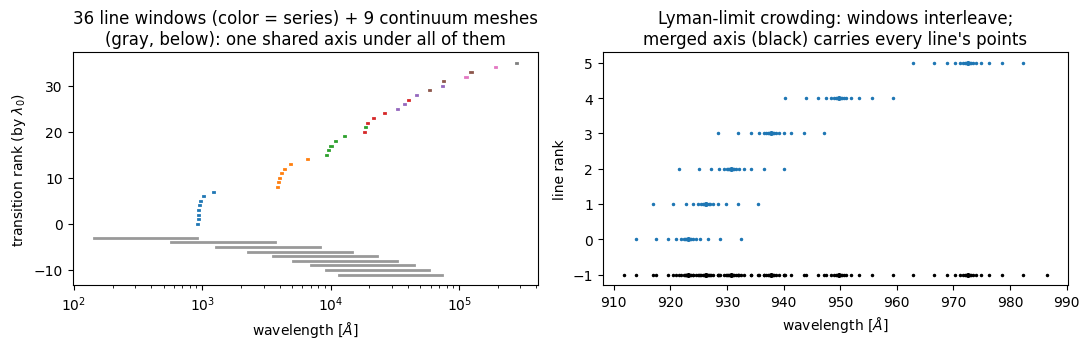

In [3]:
line_meshes, mesh, _ = build_global(300)
idxI = atom.Line["idxI"]
order = np.argsort(w0_all)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for rank, k in enumerate(order):
    axes[0].plot(
        [line_meshes[k][0] * 1e8, line_meshes[k][-1] * 1e8], [rank, rank], lw=2, color=f"C{int(idxI[k]) % 10}"
    )
for k in range(atom.nCont):
    axes[0].plot([cont_meshes[k][0] * 1e8, cont_meshes[k][-1] * 1e8], [-3 - k, -3 - k], lw=2, color="0.6")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"wavelength [$\AA$]")
axes[0].set_ylabel("transition rank (by $\\lambda_0$)")
axes[0].set_title("36 line windows (color = series) + 9 continuum meshes\n(gray, below): one shared axis under all of them")

zoom = (mesh.wl * 1e8 > 905) & (mesh.wl * 1e8 < 1000)
axes[1].plot(mesh.wl[zoom] * 1e8, np.full(zoom.sum(), -1), ".", ms=3, color="k")
for rank, k in enumerate(order[:8]):
    m = line_meshes[k]
    sel = (m * 1e8 > 905) & (m * 1e8 < 1000)
    axes[1].plot(m[sel] * 1e8, np.full(sel.sum(), rank), ".", ms=3, color=f"C{int(idxI[k]) % 10}")
axes[1].set_xlabel(r"wavelength [$\AA$]")
axes[1].set_ylabel("line rank")
axes[1].set_title("Lyman-limit crowding: windows interleave;\nmerged axis (black) carries every line's points")
plt.tight_layout()
plt.show()


## 2. The SE quadrature, static case: the two routes coincide (validation 1)

In the dual-mesh design the SE rate integral of a line at depth $k$ runs on
its own local quadrature mesh
$\lambda_L(k) = \lambda_0 + \Delta\lambda_{\rm shift}(k) + q\,\Delta\lambda_D(k)$
— recentered on the shifted core, scaled by the local width, so the Voigt
argument is exactly $q$ and the dense part of the template always sits on
the actual core. $J$ is known only where RT solved it (the global-axis
points) and is **interpolated** onto $\lambda_L(k)$.

In a **static** atmosphere with the ruler sized to the local width,
$\lambda_L$ nearly coincides with the line's window, and the dual-mesh route
must agree with direct quadrature on the window — the reference's validation
test 1, measured below for a structured radiation field (Planck times a
sine of period $4\Delta\lambda_D$) in the Ly$\alpha$ window. In both
routes, `wphi` renormalization is the accuracy lever on coarse windows: it
cancels the profile-norm part of the quadrature error exactly.

Two caveats on scope. The 40001-point grid in the code is the **error
oracle** — it defines the exact $\bar J$ that the errors are measured
against; it is never a mesh either route would own. And the specific error
magnitudes here depend on the synthetic $J$ shape chosen; this section only
establishes *agreement between the two routes* and the `wphi` mechanism —
conclusions about mesh adequacy under velocity are deferred to section 3,
which uses the measured solar spectrum instead of a synthetic $J$.


In [4]:
kLya = int(np.argmin(np.abs(w0_all - 1215.67e-8)))
w0 = float(w0_all[kLya])
dop = BasicP.doppler_width_(w0, 6000.0, 5.0e5, 1.0)


def J_field(wl):
    u = (wl - w0) / dop
    return LTELib.planck_cm_(wl, 8000.0) * (1.0 + 0.5 * np.sin(2.0 * np.pi * u / 4.0))


def phi(wl):
    x = (wl - w0) / dop
    return np.exp(-x * x) / (np.sqrt(np.pi) * dop)


wl_ref = w0 + dop * np.linspace(-12.0, 12.0, 40001)
Jbar_ref = np.trapezoid(phi(wl_ref) * J_field(wl_ref), wl_ref) / np.trapezoid(phi(wl_ref), wl_ref)


def window_jbar(nLambda):
    q = MeshUtil.make_full_line_mesh_(nLambda, 2.5, 10.0)
    win = GlobalMesh.anchor_line_mesh_(q, w0, XI_REF)
    wt = GlobalMesh.trapezoidal_weight_(win)
    ph = phi(win)
    raw = np.sum(wt * ph * J_field(win))
    return raw / np.sum(wt * ph), raw, win


def rel(x):
    return abs(x / Jbar_ref - 1.0)


J41, J41_raw, win41 = window_jbar(41)
J11, J11_raw, _ = window_jbar(11)

wl_loc = np.linspace(win41[0], win41[-1], 4001)
J_loc = np.interp(wl_loc, win41, J_field(win41))
J_interp = np.trapezoid(phi(wl_loc) * J_loc, wl_loc) / np.trapezoid(phi(wl_loc), wl_loc)

print(f"41-pt window, direct quadrature : rel err = {rel(J41):.2e}")
print(f"41-pt window, analytic norm 1   : rel err = {rel(J41_raw):.2e}")
print(f"41-pt window -> interpolated J  : rel err = {rel(J_interp):.2e}   <-- static: both routes coincide")
print(f"11-pt window, wphi renormalized : rel err = {rel(J11):.2e}")
print(f"11-pt window, analytic norm 1   : rel err = {rel(J11_raw):.2e}   <-- wphi renorm is the accuracy lever")


41-pt window, direct quadrature : rel err = 4.64e-08
41-pt window, analytic norm 1   : rel err = 2.48e-03
41-pt window -> interpolated J  : rel err = 4.20e-08   <-- static: both routes coincide
11-pt window, wphi renormalized : rel err = 2.80e-06
11-pt window, analytic norm 1   : rel err = 5.37e-02   <-- wphi renorm is the accuracy lever


## 3. Doppler shifts against the real solar spectrum (validation 3)

$J$ here is the **measured quiet-Sun atlas** (2 mÅ sampling) around
H$\alpha$ and Ca II K — the actual radiation a moving prominence/filament
sees, deep absorption cores included. $\bar J(V_{\rm los})$ is then the
Doppler brightening/dimming curve (top row) — the physics the quadrature
must protect — and no conclusion below depends on a synthetic $J$ shape.

Bookkeeping first, because it matters: **both routes read $J$ only at the
fixed global points and get the same template budget** (41 or 67 points).
The 20001-point grid in the code is the *error oracle* — it defines the
exact $\bar J$ that errors are measured against — never a mesh of either
route. And the scanned variable is not point count but **where the shifted
core lands**: in the dense core region ($V \le 25$ km/s), in the sparse
wings ($25 < V \lesssim 100$), or outside the window entirely
($V > 100$ for the RH template) — the last two are exactly the regime
where `wphi` cannot recover structure that was never sampled.

Two lines on the same 10 km/s ruler: H$\alpha$ (11.2 km/s wide — the
species that chose the ruler) and Ca II K (1.6 km/s — a narrow victim on a
shared axis). Two templates: the RH-shaped 41-point mesh (dense ±25 km/s,
extent ±100 km/s) and a 67-point mesh following the sizing rule
(`qwing` $\le$ `2*qcore` → uniform 10 km/s spacing over ±330 km/s: extent
covers the excursion; spacing targets $J$'s structure scale, *not*
$\varphi$'s width). $V_{\rm los}$ scans 0..300 km/s in 10 km/s steps.


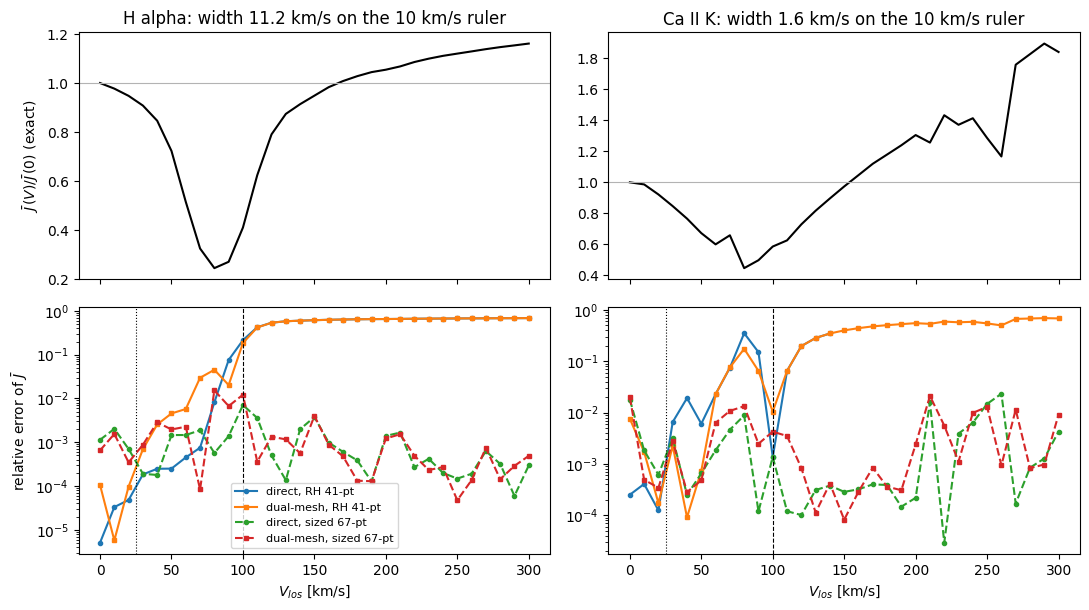

 H alpha: RH41 (V<=80) direct 8.2e-03 dual 4.5e-02 | sized67 (V<=300) direct 7.1e-03 dual 1.5e-02
 Ca II K: RH41 (V<=80) direct 3.5e-01 dual 1.7e-01 | sized67 (V<=300) direct 2.3e-02 dual 2.1e-02
Ca II K, brute force (0.8 km/s spacing, 827 points): max err 2.9e-04 -- the ~2e-2 floor of the 67-pt axis is J-structure sampling, not phi: only axis density at J's feature scale removes it, for either route


In [5]:
atlas = np.load(CFG._ROOT_DIR / "data" / "intensity" / "atlas" / "QS" / "atlas_QS.20221118.npy")

LINES = (
    ("H alpha", 6562.8e-8, BasicP.doppler_width_(6562.8e-8, 6000.0, 5.0e5, 1.0)),
    ("Ca II K", 3933.66e-8, BasicP.doppler_width_(3933.66e-8, 6000.0, 0.0, 40.08)),
)
V_grid = np.arange(0.0, 301.0, 10.0) * 1.0e5
q_rh = MeshUtil.make_full_line_mesh_(41, 2.5, 10.0)  # dense +-25 km/s, extent +-100 km/s
q_sized = MeshUtil.make_full_line_mesh_(67, 16.5, 33.0)  # uniform 10 km/s spacing, extent +-330 km/s
q_brute = MeshUtil.make_full_line_mesh_(827, 16.5, 33.0)  # uniform 0.8 km/s: resolves even Ca II K


def jbar_routes(w0L, dopL, J, V_los, q_tpl, co_moving=False):
    dlam = w0L * V_los / CST.c_

    if co_moving:
        # the background carries the slab's own shifted profile: J's sharp
        # core rides with V_los into the coarse wing region of the fixed axis
        def Jv(wl):
            return J(wl - dlam)
    else:
        Jv = J

    def phi_s(wl):
        x = (wl - w0L - dlam) / dopL
        return np.exp(-x * x) / (np.sqrt(np.pi) * dopL)

    # error ORACLE only: brute-force quadrature defining the exact Jbar.
    # neither route ever sees this grid; both get only the template points.
    wl_ref = w0L + dlam + dopL * np.linspace(-12.0, 12.0, 20001)
    ref = np.trapezoid(phi_s(wl_ref) * Jv(wl_ref), wl_ref) / np.trapezoid(phi_s(wl_ref), wl_ref)

    win = GlobalMesh.anchor_line_mesh_(q_tpl, w0L, XI_REF)  # the fixed global window
    Jwin = Jv(win)  # J is known ONLY here (RT solved it on the global axis)

    # route 1 (single-mesh): direct quadrature on the fixed window
    wt = GlobalMesh.trapezoidal_weight_(win)
    ph = phi_s(win)
    norm = np.sum(wt * ph)
    direct = np.sum(wt * ph * Jwin) / norm if norm > 0.0 else np.nan

    # route 2 (dual-mesh): same template, nodes riding the shifted core, J interpolated
    wl_loc = w0L + dlam + q_tpl * dopL  # Voigt argument is exactly q
    J_loc = np.interp(wl_loc, win, Jwin)
    wt_l = GlobalMesh.trapezoidal_weight_(wl_loc)
    ph_l = np.exp(-q_tpl * q_tpl) / (np.sqrt(np.pi) * dopL)
    dual = np.sum(wt_l * ph_l * J_loc) / np.sum(wt_l * ph_l)

    return ref, abs(direct / ref - 1.0), abs(dual / ref - 1.0)


results = {}
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2), sharex="col")
for col, (name, w0L, dopL) in enumerate(LINES):
    sel = np.abs(atlas[0] - w0L) < 25.0e-8
    awl, aI = atlas[0][sel], atlas[1][sel]

    def J_solar(wl, awl=awl, aI=aI):
        return np.interp(wl, awl, aI)  # 2 mAA atlas sampling: effectively continuous

    rh = np.array([jbar_routes(w0L, dopL, J_solar, V, q_rh) for V in V_grid])
    sz = np.array([jbar_routes(w0L, dopL, J_solar, V, q_sized) for V in V_grid])
    results[name] = (rh, sz, w0L, dopL, J_solar)

    axes[0, col].plot(V_grid / 1e5, rh[:, 0] / rh[0, 0], "k-")
    axes[0, col].axhline(1.0, color="0.7", lw=0.8)
    axes[0, col].set_title(f"{name}: width {dopL / w0L * CST.c_ / 1e5:.1f} km/s on the 10 km/s ruler")
    if col == 0:
        axes[0, col].set_ylabel(r"$\bar J(V) / \bar J(0)$ (exact)")

    curves = (
        (rh[:, 1], "direct, RH 41-pt", "o-"),
        (rh[:, 2], "dual-mesh, RH 41-pt", "s-"),
        (sz[:, 1], "direct, sized 67-pt", "o--"),
        (sz[:, 2], "dual-mesh, sized 67-pt", "s--"),
    )
    for e, lab, st in curves:
        axes[1, col].semilogy(V_grid / 1e5, np.maximum(e, 1e-12), st, ms=3, label=lab)
    axes[1, col].axvline(25.0, color="k", lw=0.8, ls=":")
    axes[1, col].axvline(100.0, color="k", lw=0.8, ls="--")
    axes[1, col].set_xlabel("$V_{los}$ [km/s]")
    if col == 0:
        axes[1, col].set_ylabel(r"relative error of $\bar J$")
        axes[1, col].legend(fontsize=8)
plt.tight_layout()
plt.show()

in80 = V_grid <= 80.0e5
for name, (rh, sz, _, _, _) in results.items():
    print(f"{name:>8}: RH41 (V<=80) direct {np.nanmax(rh[in80, 1]):.1e} dual {np.nanmax(rh[in80, 2]):.1e} | "
          f"sized67 (V<=300) direct {np.nanmax(sz[:, 1]):.1e} dual {np.nanmax(sz[:, 2]):.1e}")

_, _, w0K, dopK, J_K = results["Ca II K"]
err_bf = max(jbar_routes(w0K, dopK, J_K, V, q_brute)[1] for V in V_grid)
print(f"Ca II K, brute force (0.8 km/s spacing, {q_brute.size} points): max err {err_bf:.1e} "
      f"-- the ~2e-2 floor of the 67-pt axis is J-structure sampling, not phi: "
      f"only axis density at J's feature scale removes it, for either route")


**Reading the curves** — three regimes, set by where the shifted core lands:

- **Dense region** ($V \lesssim 25$ km/s): both routes, both templates fine
  ($\lesssim$ a few 1e-3).
- **Sparse wings** ($25 < V \lesssim 100$, RH template): the wide line that
  chose the ruler (H$\alpha$) stays accurate under *direct* quadrature
  (its $\varphi$ spans several grid points everywhere), while the narrow
  line degrades erratically (direct up to 3.5e-1). The dual-mesh route is
  the better of the two for Ca II K at moderate shifts ($V$ = 30-50 km/s:
  9e-5 .. 2e-3 vs direct 7e-3 .. 2e-2, up to a factor ~200) — but it
  cannot save the deep-wing region either: $J$'s K-core structure simply
  is not sampled there.
- **Extent violation** ($V > 100$): both routes fail identically (errors
  0.2-0.7); for $V \ge 150$ direct quadrature loses $\varphi$ support
  entirely ($0/0 \to$ nan) while the dual-mesh route stays bounded by
  $J$'s range. Extent is a build-time property of the axis, not a
  quadrature choice.

The sized 67-point template removes the extent failure completely and
bounds both routes at the **$J$-structure floor**: real spectral features
(Ca II K$_1$/K$_2$, telluric lines around H$\alpha$) at the 10 km/s grid
scale — ~2e-2 for Ca II K, ~1e-2 for H$\alpha$, similar for both routes.
The brute-force print confirms it: only axis density at $J$'s feature
scale removes that floor.


### 3a. Anatomy at $V = 0$: error in the values vs error in the weights

A counterintuitive detail of the scan above: at $V = 0$ the dual-mesh
route is an order of magnitude *worse* than direct quadrature for Ca II K
(7.6e-3 vs 2.5e-4), even though it samples $\varphi$ perfectly. The
anatomy below shows the mechanism. Both routes own **exactly the same
information** — $J$ at the global-axis nodes (~1.9 km/s core spacing) —
and differ only in where they put the error:

- **direct = exact values, wrong weights.** It reads true $J$ at the axis
  nodes. Its $\varphi$ sampling is poor (a 1.6 km/s Gaussian read every
  1.9 km/s), but `wphi` renormalization makes the weights sum to one and
  the node set is symmetric about the core, so the estimate is exact for
  any locally *linear* $J$; the residual is second order.
- **dual = exact weights, wrong values.** $\varphi$ and the quadrature
  weights are exact at the local nodes, but the $J$ it integrates is a
  **chord** — linear interpolation between axis nodes. Under curvature
  the chord error ($\sim h^2 J''/8$) is one-signed, and $\varphi$-weighting
  accumulates it instead of cancelling it: the $\varphi$-weighted chord
  bias printed below equals the dual route's entire error, digit for
  digit.
- **dual(exact J)** is a diagnostic, not a route: the oracle $J$ evaluated
  directly at the local nodes, bypassing the global axis (impossible in a
  real solver, where $J$ exists only on the axis). At ~1e-5 it clears
  node placement and weights — everything above it is the single
  global → local interpolation step. There is no double interpolation:
  the atlas → axis evaluation is common to every route and the atlas grid
  is ~13 times finer than the axis; in the real solver $J$ is *born* on
  the axis.

Why $V = 0$ is the worst case is generic, not an accident of this
spectrum: at $V = 0$, $\varphi$ sits on its own line's core — exactly
where the radiation field's curvature is physically largest, because the
same transition carves that feature into $J$ (the plot shows the measured
K-core dip sitting +4 km/s from the laboratory wavelength, so $\varphi$
rides its curved shoulder). Only the *magnitude* is shape-dependent: at
$V = 20$ km/s the core has moved onto the quasi-linear wing and the two
routes agree at the same order — the chord bias collapses with $J''$.
For a narrow line on a shared ruler this penalty exists even in a fully
static solver: the dual route's local mesh (scaled by the 1.6 km/s local
width) never coincides with the axis nodes, so it interpolates at $V = 0$
too.


Ca II K V=  0: err direct 2.5e-04 | dual 7.6e-03 | dual(exact J) 1.3e-05 | phi-weighted chord bias -7.6e-03
Ca II K V= 20: err direct 1.2e-04 | dual 1.7e-04 | dual(exact J) 2.5e-05 | phi-weighted chord bias -2.0e-04


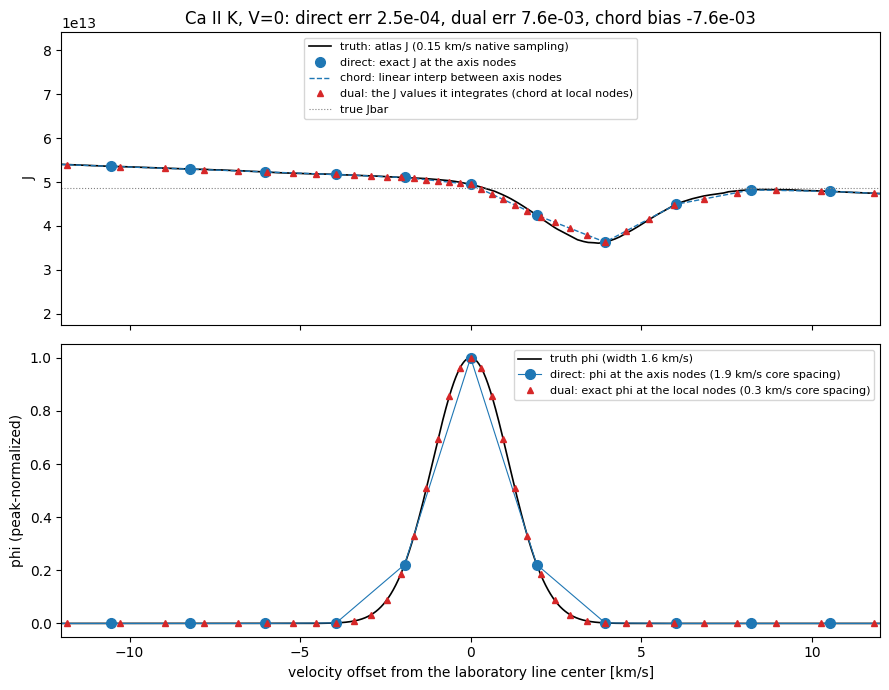

In [6]:
def chord_anatomy_(w0L, dopL, J, V_los, q_tpl):
    dlam = w0L * V_los / CST.c_

    def phi_s(wl):
        x = (wl - w0L - dlam) / dopL
        return np.exp(-x * x) / (np.sqrt(np.pi) * dopL)

    wl_ref = w0L + dlam + dopL * np.linspace(-12.0, 12.0, 20001)  # error oracle
    ref = np.trapezoid(phi_s(wl_ref) * J(wl_ref), wl_ref) / np.trapezoid(phi_s(wl_ref), wl_ref)
    win = GlobalMesh.anchor_line_mesh_(q_tpl, w0L, XI_REF)
    wt = GlobalMesh.trapezoidal_weight_(win)
    ph = phi_s(win)
    direct = np.sum(wt * ph * J(win)) / np.sum(wt * ph)
    wl_loc = w0L + dlam + q_tpl * dopL
    J_chord = np.interp(wl_loc, win, J(win))  # the design's one in-loop interpolation
    wt_l = GlobalMesh.trapezoidal_weight_(wl_loc)
    ph_l = np.exp(-q_tpl * q_tpl) / (np.sqrt(np.pi) * dopL)
    W = wt_l * ph_l / np.sum(wt_l * ph_l)
    dual = np.sum(W * J_chord)
    dual_xJ = np.sum(W * J(wl_loc))  # diagnostic: oracle J straight at the local nodes
    bias = np.sum(W * (J_chord - J(wl_loc))) / ref
    return ref, direct, dual, dual_xJ, bias, win, wl_loc, J_chord


for V in (0.0, 20.0e5):
    ref, direct, dual, dual_xJ, bias, _, _, _ = chord_anatomy_(w0K, dopK, J_K, V, q_rh)
    print(f"Ca II K V={V / 1e5:3.0f}: err direct {abs(direct / ref - 1.0):.1e} | dual {abs(dual / ref - 1.0):.1e}"
          f" | dual(exact J) {abs(dual_xJ / ref - 1.0):.1e} | phi-weighted chord bias {bias:+.1e}")

ref, direct, dual, _dxj, bias, win, wl_loc, J_chord = chord_anatomy_(w0K, dopK, J_K, 0.0, q_rh)
vv = np.linspace(-12.0, 12.0, 2001)
wl_dense = w0K * (1.0 + vv * 1e5 / CST.c_)
v_win = (win - w0K) / w0K * CST.c_ / 1e5
v_loc = (wl_loc - w0K) / w0K * CST.c_ / 1e5
m = np.abs(v_loc) < 12.0

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(vv, J_K(wl_dense), "k-", lw=1.2, label="truth: atlas J (0.15 km/s native sampling)")
axes[0].plot(v_win, J_K(win), "o", color="tab:blue", ms=7, label="direct: exact J at the axis nodes")
axes[0].plot(vv, np.interp(wl_dense, win, J_K(win)), "--", color="tab:blue", lw=1.0,
             label="chord: linear interp between axis nodes")
axes[0].plot(v_loc[m], J_chord[m], "^", color="tab:red", ms=4,
             label="dual: the J values it integrates (chord at local nodes)")
axes[0].axhline(ref, color="0.5", lw=0.8, ls=":", label="true Jbar")
axes[0].set_ylabel("J")
axes[0].legend(fontsize=8, loc="upper center")
axes[0].set_title(f"Ca II K, V=0: direct err {abs(direct / ref - 1.0):.1e}, "
                  f"dual err {abs(dual / ref - 1.0):.1e}, chord bias {bias:+.1e}")

ph_dense = np.exp(-(((wl_dense - w0K) / dopK) ** 2))
axes[1].plot(vv, ph_dense, "k-", lw=1.2, label="truth phi (width 1.6 km/s)")
axes[1].plot(v_win, np.exp(-(((win - w0K) / dopK) ** 2)), "o-", color="tab:blue", ms=7, lw=0.8,
             label="direct: phi at the axis nodes (1.9 km/s core spacing)")
axes[1].plot(v_loc[m], np.exp(-q_rh * q_rh)[m], "^", color="tab:red", ms=4,
             label="dual: exact phi at the local nodes (0.3 km/s core spacing)")
axes[1].set_xlabel("velocity offset from the laboratory line center [km/s]")
axes[1].set_ylabel("phi (peak-normalized)")
axes[1].legend(fontsize=8)
axes[1].set_xlim(-12.0, 12.0)
plt.tight_layout()
plt.show()


**The other failure mode, anatomized: H$\alpha$ at $V = 100$ km/s
(extent violation).** Same decomposition, different failure. At $V = 100$
the shifted core sits exactly on the window's last node — beyond it the
axis has **no $J$ at all**, so the problem is no longer curvature between
nodes but *missing information past the edge*. Direct quadrature can only
integrate the blue half of $\varphi$ that still has support (truncation);
the dual route's local nodes march past the edge, where interpolation
degenerates to clamping $J$ at the edge value (flat extrapolation). Both
answers are wrong by O(0.2) — comparable, one-sided, and no quadrature
choice can repair them. This is the picture behind "extent is a
build-time obligation of the axis": the sized 67-point template exists
precisely to keep every reachable core inside the sampled range. The
$V = 50$ row also shows the chord mechanism of the Ca II K anatomy at
work on the wide line — inside the extent, direct stays at a few 1e-4
while the dual route pays a few 1e-3 of chord bias for wing-spacing
interpolation.


H alpha V=  0: err direct 5.1e-06 | dual 1.1e-04 | dual(exact J) 1.7e-05 | phi-weighted chord bias -8.9e-05
H alpha V= 50: err direct 2.5e-04 | dual 4.6e-03 | dual(exact J) 4.0e-05 | phi-weighted chord bias -4.5e-03
H alpha V=100: err direct 2.1e-01 | dual 1.8e-01 | dual(exact J) 1.3e-04 | phi-weighted chord bias -1.8e-01


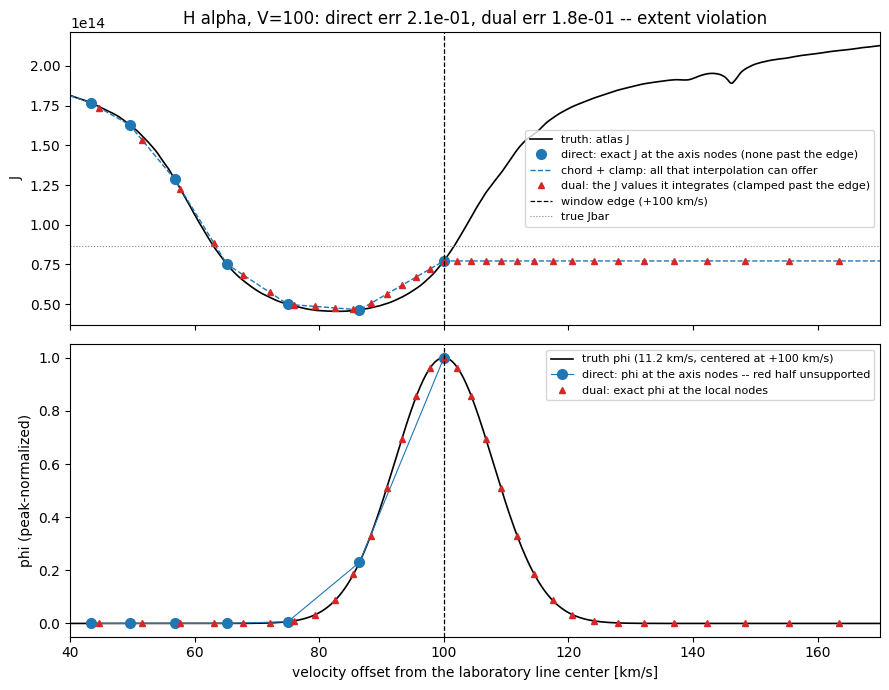

In [7]:
_rh_H, _sz_H, w0H, dopH, J_H = results["H alpha"]
for V in (0.0, 50.0e5, 100.0e5):
    ref, direct, dual, dual_xJ, bias, _, _, _ = chord_anatomy_(w0H, dopH, J_H, V, q_rh)
    print(f"H alpha V={V / 1e5:3.0f}: err direct {abs(direct / ref - 1.0):.1e} | dual {abs(dual / ref - 1.0):.1e}"
          f" | dual(exact J) {abs(dual_xJ / ref - 1.0):.1e} | phi-weighted chord bias {bias:+.1e}")

ref, direct, dual, _dxj, bias, win, wl_loc, J_chord = chord_anatomy_(w0H, dopH, J_H, 100.0e5, q_rh)
vv = np.linspace(40.0, 170.0, 2001)
wl_dense = w0H * (1.0 + vv * 1e5 / CST.c_)
v_win = (win - w0H) / w0H * CST.c_ / 1e5
v_loc = (wl_loc - w0H) / w0H * CST.c_ / 1e5
mw = (v_win > 40.0) & (v_win < 170.0)
ml = (v_loc > 40.0) & (v_loc < 170.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(vv, J_H(wl_dense), "k-", lw=1.2, label="truth: atlas J")
axes[0].plot(v_win[mw], J_H(win[mw]), "o", color="tab:blue", ms=7,
             label="direct: exact J at the axis nodes (none past the edge)")
axes[0].plot(vv, np.interp(wl_dense, win, J_H(win)), "--", color="tab:blue", lw=1.0,
             label="chord + clamp: all that interpolation can offer")
axes[0].plot(v_loc[ml], J_chord[ml], "^", color="tab:red", ms=4,
             label="dual: the J values it integrates (clamped past the edge)")
axes[0].axvline(100.0, color="k", lw=0.9, ls="--", label="window edge (+100 km/s)")
axes[0].axhline(ref, color="0.5", lw=0.8, ls=":", label="true Jbar")
axes[0].set_ylabel("J")
axes[0].legend(fontsize=8)
axes[0].set_title(f"H alpha, V=100: direct err {abs(direct / ref - 1.0):.1e}, "
                  f"dual err {abs(dual / ref - 1.0):.1e} -- extent violation")

dlam100 = w0H * 100.0e5 / CST.c_
ph_dense = np.exp(-(((wl_dense - w0H - dlam100) / dopH) ** 2))
axes[1].plot(vv, ph_dense, "k-", lw=1.2, label="truth phi (11.2 km/s, centered at +100 km/s)")
axes[1].plot(v_win[mw], np.exp(-(((win[mw] - w0H - dlam100) / dopH) ** 2)), "o-", color="tab:blue",
             ms=7, lw=0.8, label="direct: phi at the axis nodes -- red half unsupported")
axes[1].plot(v_loc[ml], np.exp(-q_rh * q_rh)[ml], "^", color="tab:red", ms=4,
             label="dual: exact phi at the local nodes")
axes[1].axvline(100.0, color="k", lw=0.9, ls="--")
axes[1].set_xlabel("velocity offset from the laboratory line center [km/s]")
axes[1].set_ylabel("phi (peak-normalized)")
axes[1].legend(fontsize=8)
axes[1].set_xlim(40.0, 170.0)
plt.tight_layout()
plt.show()


### 3b. The co-moving background: a shifted $J$ core on coarse wing spacing

The static atlas above keeps $J$'s features at their rest wavelengths — the
densely sampled region — so only $\varphi$ moves. The complementary, and
**harder**, case is a *co-moving* background: inside an optically thick
moving slab, the radiation field carries the slab's own line profile,
shifted with $V_{\rm los}$ — so $J$'s sharp core lands exactly where the
fixed axis is coarsest. Physically both cases coexist: incident
(chromospheric) radiation is static in the observer frame, the internally
generated field is co-moving.

The printed sanity check confirms the setup: $\bar J(V)$ is now
$V$-independent (the profile always sees its own co-moving core). The error
floor changes character: it becomes **the sampling of $J$'s shifted core by
the global grid**, it hits *both* routes equally, and no interpolation can
recover structure that was never sampled — the mesh density over the whole
excursion band must be sized to $J$'s feature width. The dual-mesh route
neither wins nor loses here: its advantage lives entirely on the
$\varphi$ side (narrow-line exactness at unchanged $N_{\rm spect}$), never
on the $J$ side.


 H alpha: max |Jbar(V)/Jbar(0) - 1| = 5.1e-14 (flat: the profile sees its own core); sized67 floor over all V: direct 1.2e-03, dual 6.5e-04
 Ca II K: max |Jbar(V)/Jbar(0) - 1| = 1.1e-12 (flat: the profile sees its own core); sized67 floor over all V: direct 1.8e-02, dual 2.0e-02


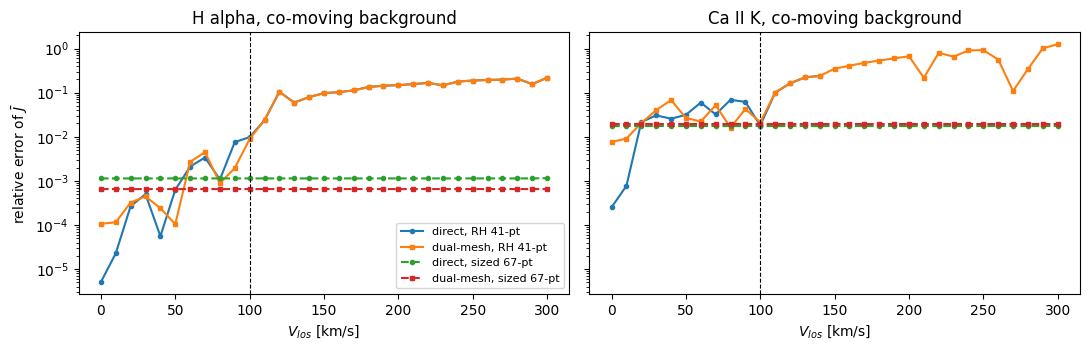

Ca II K co-moving, 0.8 km/s brute force: direct max err 1.5e-04 -- the floor is J-structure sampling; only density over the excursion band removes it


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for col, (name, (_rh, _sz, w0L, dopL, J_solar)) in enumerate(results.items()):
    rh_cm = np.array([jbar_routes(w0L, dopL, J_solar, V, q_rh, co_moving=True) for V in V_grid])
    sz_cm = np.array([jbar_routes(w0L, dopL, J_solar, V, q_sized, co_moving=True) for V in V_grid])
    curves = (
        (rh_cm[:, 1], "direct, RH 41-pt", "o-"),
        (rh_cm[:, 2], "dual-mesh, RH 41-pt", "s-"),
        (sz_cm[:, 1], "direct, sized 67-pt", "o--"),
        (sz_cm[:, 2], "dual-mesh, sized 67-pt", "s--"),
    )
    for e, lab, st in curves:
        axes[col].semilogy(V_grid / 1e5, np.maximum(e, 1e-12), st, ms=3, label=lab)
    axes[col].axvline(100.0, color="k", lw=0.8, ls="--")
    axes[col].set_xlabel("$V_{los}$ [km/s]")
    axes[col].set_title(f"{name}, co-moving background")
    print(f"{name:>8}: max |Jbar(V)/Jbar(0) - 1| = {np.abs(rh_cm[:, 0] / rh_cm[0, 0] - 1.0).max():.1e} "
          f"(flat: the profile sees its own core); sized67 floor over all V: "
          f"direct {np.nanmax(sz_cm[:, 1]):.1e}, dual {np.nanmax(sz_cm[:, 2]):.1e}")
axes[0].set_ylabel(r"relative error of $\bar J$")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

err_bf_cm = max(jbar_routes(w0K, dopK, J_K, V, q_brute, co_moving=True)[1] for V in V_grid)
print(f"Ca II K co-moving, 0.8 km/s brute force: direct max err {err_bf_cm:.1e} -- "
      f"the floor is J-structure sampling; only density over the excursion band removes it")


## 4. Input-side seam: cross-section tables → global axis

Photoionization cross sections are tabulated (here `PI.alpha_interp`, 41
points per continuum on `Cont_mesh`) and interpolated **once, before the
loop** onto the global axis — the one genuine table → global interpolation of
the pipeline. For hydrogen the exact analytic $\alpha$ exists
(`Hydrogen.PI_cross_section_cm_`), so the resampling error is directly
measurable; the timing shows why doing this per-iteration would be waste and
per-model is free.


alpha (Lyman continuum), 41-pt table -> 2001 wavelengths, linear : max rel err = 8.7e-02, mean = 6.7e-03
alpha (Lyman continuum), 41-pt table -> 2001 wavelengths, log-log: max rel err = 1.0e-03
linear-interp error concentrates in the coarse short-wavelength tail (alpha spans ~2.5 decades there)
all 9 continua onto the 1837-point global axis: 54 us per full pass


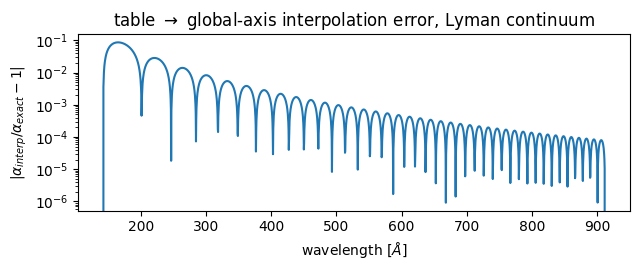

In [9]:
cm0 = atom._wave_mesh.Cont_mesh[0][::-1]  # Lyman continuum, ascending
ai0 = atom.PI.alpha_interp[0][::-1]
wl_t = np.linspace(cm0[0], cm0[-1], 2001)
exact = Hydrogen.PI_cross_section_cm_(1, wl_t, 1)
approx = np.interp(wl_t, cm0, ai0)
rel_alpha = np.abs(approx / exact - 1.0)
approx_log = np.exp(np.interp(np.log(wl_t), np.log(cm0), np.log(ai0)))
rel_alpha_log = np.abs(approx_log / exact - 1.0)
print(f"alpha (Lyman continuum), 41-pt table -> 2001 wavelengths, linear : max rel err = {rel_alpha.max():.1e}, mean = {rel_alpha.mean():.1e}")
print(f"alpha (Lyman continuum), 41-pt table -> 2001 wavelengths, log-log: max rel err = {rel_alpha_log.max():.1e}")
print("linear-interp error concentrates in the coarse short-wavelength tail (alpha spans ~2.5 decades there)")

reps = 200
t0 = time.perf_counter()
for _ in range(reps):
    for kc in range(atom.nCont):
        np.interp(mesh.wl, atom._wave_mesh.Cont_mesh[kc][::-1], atom.PI.alpha_interp[kc][::-1])
dt_alpha = (time.perf_counter() - t0) / reps
print(f"all {atom.nCont} continua onto the {mesh.wl.size}-point global axis: {dt_alpha * 1e6:.0f} us per full pass")

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.semilogy(wl_t * 1e8, rel_alpha)
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"|$\alpha_{interp}/\alpha_{exact} - 1$|")
ax.set_title("table $\\to$ global-axis interpolation error, Lyman continuum")
plt.tight_layout()
plt.show()


## 5. Output-side seam: emergent intensity → observational mesh

The only global → local interpolation is on **intensity, after convergence**:
resampling the emergent spectrum from the global axis onto a per-line or
observational mesh. Its error never feeds back into the solution. Measured on
a fabricated Ly$\alpha$ emission profile ($I = 1 + 4e^{-x^2}$), linear
resampling converges quadratically with window resolution:


In [10]:
def I_line(wl):
    x = (wl - w0) / dop
    return 1.0 + 4.0 * np.exp(-x * x)


for nLambda in (41, 81, 161):
    q = MeshUtil.make_full_line_mesh_(nLambda, 2.5, 10.0)
    win = GlobalMesh.anchor_line_mesh_(q, w0, XI_REF)
    wl_obs = np.linspace(win[0], win[-1], 2001)
    t0 = time.perf_counter()
    for _ in range(1000):
        I_res = np.interp(wl_obs, win, I_line(win))
    dt = (time.perf_counter() - t0) / 1000
    err = np.abs(I_res / I_line(wl_obs) - 1.0).max()
    print(f"{nLambda:>4}-pt window -> 2001-pt observational mesh: max rel err = {err:.1e}   ({dt * 1e6:.0f} us)")


  41-pt window -> 2001-pt observational mesh: max rel err = 1.7e-02   (9 us)
  81-pt window -> 2001-pt observational mesh: max rel err = 3.9e-03   (9 us)


 161-pt window -> 2001-pt observational mesh: max rel err = 9.3e-04   (9 us)


## Summary

| seam | direction | what moves | when | measured here |
|---|---|---|---|---|
| cross-section tables | local table → global axis | opacity data $\alpha(\lambda)$ | once, before the loop | linear: 2e-3 near threshold but 9e-2 in the coarse tail; log-log: 1e-3 everywhere; ~50 us per full pass |
| SE rate integral | global axis → local shifted quadrature mesh | mean intensity $J$ (and the operator $\Psi$) | every iteration — the dual-mesh design's one deliberate in-loop approximation | static: the routes coincide (~5e-8 both); real solar $J$: dual-mesh up to ~200 times better on the narrow line at moderate shifts (Ca II K, $V$=30-50) and stays bounded where direct loses $\varphi$ support (nan); extent violation ($V$>100 on the RH template) kills both routes; the $J$-structure floor (~2e-2 for Ca II K at 10 km/s spacing; the whole story in the co-moving case) hits both routes equally |
| emergent spectrum | global axis → observational mesh | intensity | once, after convergence | quadratic in window resolution (2e-2 → 9e-4 from 41 to 161 pts), error does not feed back |

The direct answer to "should $J$ be interpolated to the local mesh for the
SE calculation": **yes — that is the dual-mesh design.** RT needs the
global axis (the formal solve is monochromatic and pointwise-exact there);
the SE quadrature needs its nodes registered to the *shifted, locally
scaled* line core, which the fixed axis cannot provide under velocity; $J$
bridges the two by interpolation, and that is the right place for the
approximation because in the product $\varphi J$ the sharp factor
($\varphi$, analytic, free anywhere) stays exact while the error lands on
the smooth factor ($J$, feature width floored at the smallest Doppler width
in the atmosphere). In the **static** case the two routes coincide
(section 2), so a static solver may accumulate directly on the window
without error.

What velocity actually demands, measured against the real solar spectrum
(section 3): the dominant obligations are **build-time properties of the
axis itself**, binding *both* routes — extent must cover the full velocity
excursion (beyond it both fail identically at 0.2-0.7), and density over
the excursion band must resolve $J$'s real feature scale (the co-moving
benchmark shows this floor hitting both routes equally; no interpolation,
and no `wphi`, recovers structure the axis never sampled — for Ca II K the
10 km/s axis floors both routes at ~2e-2 and only 0.8 km/s spacing reaches
~2e-4). What the dual mesh contributes at run time is the $\varphi$ side:
the Voigt argument is exactly $q$, so the profile norm stays exact and the
rate integral never loses $\varphi$ support (direct quadrature returns nan
once a narrow line's shifted core leaves the grid's support, and is up to
~200 times less accurate at moderate shifts, $V$ = 30-50 km/s, at
identical $N_{\rm spect}$). It does not — cannot — lower the
$J$-structure floor; that is the axis density's job.

Real-hydrogen mesh facts to carry into full MALI: the axis is
transition-complete by construction (lines and continua alike get windows;
ignoring a window is a consumer's choice, never the builder's);
window overlap is a wing-extent property (Doppler-only wings
keep hydrogen's lines disjoint; damping wings chain the Lyman series), and
a continuum window swallows every interleaved point below its threshold —
so the sweep must accumulate **per-column opacity across the active set**
before overlap can be handled; dedup fires only on coincident points,
which the continuum meshes (not the lines) produce; merging is milliseconds
even at damping-wing sizes; and cross-section tables should be interpolated
in log-log, which flattens the tail error from 9e-2 to 1e-3 at no extra
cost.
